# Sudoku as Constraint Search

Each blank is a variable with candidates 1 through 9. Rows, columns, and 3-by-3 boxes must contain no repeated digit. This is a **constraint satisfaction problem (CSP)**.

Compare a straightforward backtracking solver with a domain-reduction demonstration on the same puzzle. Run the cells in order with Matplotlib installed. The saved results are specific to this puzzle, not a benchmark across Sudoku instances.


## Imports and Puzzle

The puzzle is a list of nine row lists. Zero represents an unassigned cell, not a Sudoku digit. The nonzero entries are fixed clues.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# show a sudoku problem
puzzle = [
    [5, 3, 0, 0, 7, 0, 0, 0, 0],
    [6, 0, 0, 1, 9, 5, 0, 0, 0],
    [0, 9, 8, 0, 0, 0, 0, 6, 0],
    [8, 0, 0, 0, 6, 0, 0, 0, 3],
    [4, 0, 0, 8, 0, 3, 0, 0, 1],
    [7, 0, 0, 0, 2, 0, 0, 0, 6],
    [0, 6, 0, 0, 0, 0, 2, 8, 0],
    [0, 0, 0, 4, 1, 9, 0, 0, 5],
    [0, 0, 0, 0, 8, 0, 0, 7, 9]
]



## Draw the Grid

The helper writes only nonzero entries, draws thin cell boundaries, and emphasizes each 3-by-3 box. The vertical coordinate is flipped so list row 0 appears at the top. Drawing does not validate a solution.


In [ ]:
def 

## Inspect the Starting State

Choose one blank and eliminate digits already present in its row, column, and box. That manual candidate test is what the next helper automates.

<details class="notebook-answers">
<summary>Example answer</summary>

Using zero-based indices, choose `(0, 2)`. Its row excludes 3, 5, and 7; its column excludes 8; and its box excludes 3, 5, 6, 8, and 9. The remaining candidates are **1, 2, and 4**. This is a local legality check, not a guarantee that all three candidates extend to a full solution.

</details>


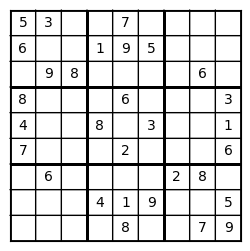

In [ ]:
draw_puzzle(puzzle):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_aspect('equal')
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_patch(patches.Rectangle((0, 0), 9, 9, fill=False))
    for i in range(9):
        for j in range(9):
            if puzzle[i][j] != 0:
                ax.text(j + 0.5, 8.5 - i, str(puzzle[i][j]), ha='center', va='center')
    for i in range(3):
        for j in range(3):
            ax.add_patch(patches.Rectangle((3 * j, 3 * i), 3, 3, fill=False
                , linewidth=2))
    for i in range(8):
        ax.add_patch(patches.ConnectionPatch((i + 1, 0), (i + 1, 9), 'data', 'data'))
        ax.add_patch(patches.ConnectionPatch((0, i + 1), (9, i + 1), 'data', 'data'))
    plt.show()

draw_puzzle(puzzle)

## Check a Candidate

<code>is_valid(puzzle, i, j, n)</code> checks whether digit <code>n</code> conflicts with an existing entry in the row, column, or box of a blank cell. Integer division identifies the upper-left corner of the box.

The counters below record recursive calls and ensure the successful board is printed once. Reset them before comparing repeated runs.


In [ ]:
def is_valid(puzzle, i, j, n):
    for k in range(9):
        if puzzle[i][k] == n or puzzle[k][j] == n:
            return False
    for k in range(3):
        for l in range(3):
            if puzzle[(i // 3) * 3 + k][(j // 3) * 3 + l] == n:
                return False
    return True

success_flag = False
num = 0



## Backtrack Through Assignments

The solver chooses the first blank in row-major order and tries digits from 1 through 9. A legal digit is written into the board before recursion. If the recursive call fails, the cell is reset to zero before trying another digit.

No blanks means success. Exhausting candidates at a blank means failure. This implementation assumes the supplied clues are valid; it is not a separate validator for arbitrary filled boards. The recursion mutates its argument, so later runs pass a deep copy.


In [ ]:
def solve(puzzle):
    global success_flag, num
    num += 1
    for i in range(9):
        for j in range(9):
            if puzzle[i][j] == 0:
                for n in range(1, 10):
                    if is_valid(puzzle, i, j, n):
                        puzzle[i][j] = n
                        if solve(puzzle):
                            if not success_flag:
                                print("success with ", num, " steps")
                                draw_puzzle(puzzle)
                                success_flag = True
                            return True
                        puzzle[i][j] = 0
                return False
    return True



## Represent Candidate Domains

Every coordinate maps to a set of candidates. Blank cells initially allow all digits; clue cells begin with a singleton set. Domain reduction can make forced assignments before branching.


In [ ]:
# solve the sudoku problem by reducing the search space with inference
# generate a dictionary of possible values for each cell
all_cells = [(i, j) for i in range(9) for j in range(9)]
possible_values = {cell: set(range(1, 10)) for cell in all_cells}
for i in range(9):
    for j in range(9):
        if puzzle[i][j] != 0:
            possible_values[(i, j)] = set(puzzle[i][j] for _ in range(1))



## Remove an Assigned Digit from Peers

<code>infer</code> removes the assigned digit from candidates in the same row, column, and box. If an unresolved peer loses its last candidate, it returns <code>False</code>.

This demonstration uses an unusual convention: a processed cell has an **empty** set because its singleton was consumed with <code>pop()</code>. An unresolved cell becoming empty means failure, while an already processed empty set is skipped. Distinguishing assigned cells explicitly would make a general solver easier to reason about.


In [ ]:
import copy
def infer(possible_values, i, j, n):
    for k in range(9):
        if n in possible_values[(i, k)]:
            possible_values[(i, k)].remove(n)
            if len(possible_values[(i, k)]) == 0:
                return False
        if n in possible_values[(k, j)]:
            possible_values[(k, j)].remove(n)
            if len(possible_values[(k, j)]) == 0:
                return False
    for k in range(3):
        for l in range(3):
            if n in possible_values[(i // 3 * 3 + k, j // 3 * 3 + l)]:
                possible_values[(i // 3 * 3 + k, j // 3 * 3 + l)].remove(n)
                if len(possible_values[(i // 3 * 3 + k, j // 3 * 3 + l)]) == 0:
                    return False
    return True

num_reduce = 0


## Propagate Forced Values

The function copies the board and candidate dictionary, then ranks cells by domain size. Singleton candidates are assigned and removed from peers. Repeated recursive passes can reveal further singletons.

**Scope of this demonstration:** the supplied puzzle is solved by propagation. The fallback branching code writes a guessed digit into the board but does not restrict that cell's domain or propagate the guess. It is therefore not a complete inference-plus-backtracking solver for arbitrary puzzles. Do not interpret its success here as evidence that harder instances will terminate correctly.


In [ ]:
def solve_reduce(puzzle, possible_values):
    global num_reduce
    num_reduce += 1
    copy_possible_values = copy.deepcopy(possible_values)
    copy_puzzle = copy.deepcopy(puzzle)
    # rank the cells by the number of possible values
    cells = sorted(all_cells, key=lambda cell: len(copy_possible_values[cell]))
    for cell in cells:
        if len(copy_possible_values[cell]) == 1:
            n = copy_possible_values[cell].pop()
            copy_puzzle[cell[0]][cell[1]] = n
            if not infer(copy_possible_values, cell[0], cell[1], n):
                return False
    if all(len(copy_possible_values[cell]) == 0 for cell in all_cells):
        print("success with ", num_reduce, " steps")
        draw_puzzle(copy_puzzle)
        return True
    for cell in cells:
        if len(copy_possible_values[cell]) > 1:
            for n in copy_possible_values[cell]:
                copy_puzzle[cell[0]][cell[1]] = n
                if solve_reduce(copy_puzzle, copy_possible_values):
                    return True
            return False
    return False





## Run Plain Backtracking

The deep copy protects the original clues. The saved run reports 4,209 recursive calls and displays the solved board. The printed word "steps" refers to function calls, not individual constraint checks.


success with  4209  steps


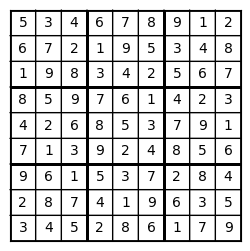

In [ ]:
solve(copy.deepcopy(puzzle))


## Run Domain Reduction

The saved run reports four recursive calls for this puzzle. A propagation call can scan many cells and candidates, so four versus 4,209 calls is not a direct timing ratio. The final <code>True</code> is the returned success flag.


success with  4  steps


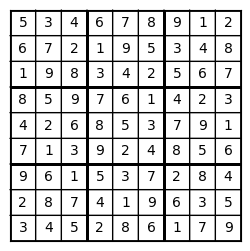

True

In [ ]:
solve_reduce(copy.deepcopy(puzzle), possible_values)

## Compare the Two Approaches

- Confirm that every original clue is unchanged in the displayed solutions.
- Trace where plain backtracking undoes a choice and where inference removes a candidate.
- Explain why choosing a cell with few remaining values can reduce branching. This is the **minimum remaining values (MRV)** heuristic.
- Before extending the inference solver, specify how a guessed value should update its domain and how failure should restore the previous state.

<details class="notebook-answers">
<summary>Answers and discussion</summary>

1. **Check the clues independently of the blanks.** Every initially nonzero entry must equal the corresponding final entry. For example, the original top-row 5, 3, and 7 retain their positions. Plain backtracking writes only into zeros; the inference version initializes each clue with exactly its given digit. A complete solution also needs each row, column, and box to contain digits 1 through 9.
2. **Undo versus eliminate.** In `solve`, the line `puzzle[i][j] = 0` restores a blank after a recursive branch fails. In `infer`, calls to `.remove(n)` delete an assigned digit from peer domains. Backtracking reverses a tentative assignment; inference rules out conflicting candidates before trying them.
3. **MRV exposes difficult choices early.** A cell with two candidates creates at most two branches, while one with eight creates up to eight. A singleton is forced, and an unresolved empty domain signals failure. MRV often reduces wasted search by finding constrained decisions and contradictions early, but does not guarantee the smallest search tree on every puzzle.
4. **A guess must change the search state.** On a branch-local copy, restrict the chosen cell's domain to `{n}`, assign or propagate it using a consistent assigned-cell convention, and continue inference before recursion. If the branch fails, discard that copy or restore every changed domain and board entry. The current fallback only writes the board entry; without restricting the domain, recursion can revisit the same unresolved choice.

</details>

**Takeaway:** inference can avoid search, but a general solver still needs correct state management and branching when propagation stalls.
